<a href="https://colab.research.google.com/github/Renju-rl/Git-hub-DSA/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split


In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# n_iris = iris.drop(columns = 'species')
n_iris = iris.drop(columns='species').drop_duplicates().reset_index(drop=True)

In [ ]:
n_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [ ]:
n_iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
num_col = n_iris.select_dtypes(include = ['float64','int64'])

In [ ]:
n_iris.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0


In [ ]:
n_iris.duplicated().sum()

np.int64(0)

In [ ]:
n_iris = n_iris.drop_duplicates()

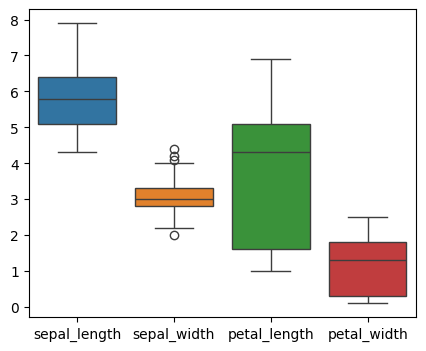

In [ ]:
plt.figure(figsize = (5,4))
sns.boxplot(data = n_iris)
plt.show()

In [ ]:
q1 = n_iris['sepal_width'].quantile(0.25)
q3 = n_iris['sepal_width'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

n_iris['sepal_width'] = n_iris['sepal_width'].clip(lower = lower , upper = upper)

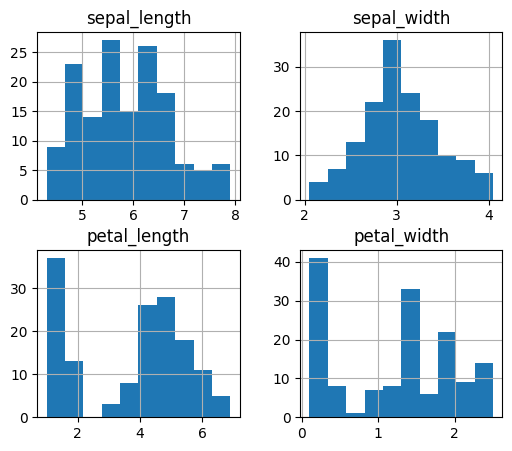

In [ ]:
n_iris.hist(figsize = (6,5))
plt.show()

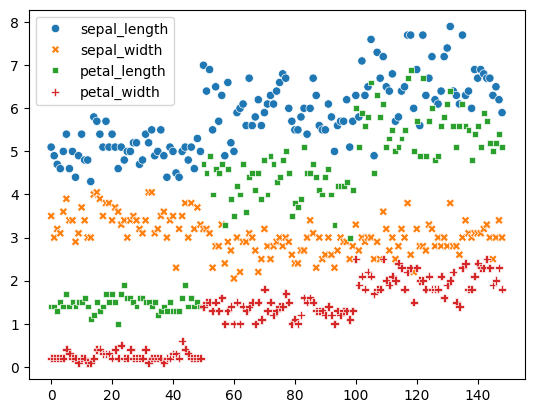

In [ ]:
sns.scatterplot(data = n_iris)
plt.show()

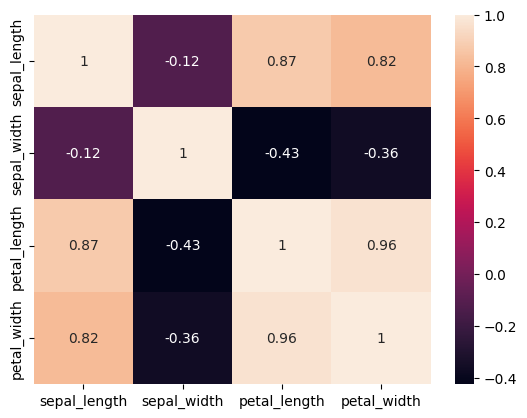

In [ ]:
sns.heatmap(n_iris.corr(numeric_only = True), annot = True)
plt.show()

In [ ]:
s = StandardScaler()
X_scaled = s.fit_transform(num_col)

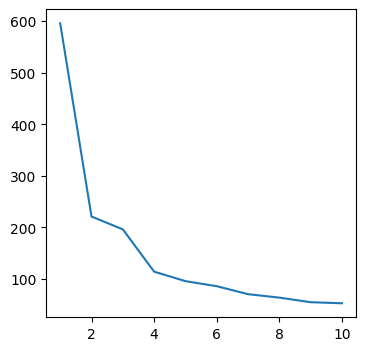

In [ ]:
wcss = []

for i in range(1,11):
  kmean = KMeans(n_clusters = i , random_state = 42)
  kmean.fit(X_scaled)
  wcss.append(kmean.inertia_)
plt.figure(figsize = (4,4))
plt.plot(range(1,11),wcss)
plt.show()

In [ ]:
kmean = KMeans(n_clusters = 4 , random_state = 42)
n_iris['cluster'] = kmean.fit_predict(X_scaled)
y_pred = kmean.predict(X_scaled)

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_pred)

print("Silhouette Score:", score)

Silhouette Score: 0.39859004045674723


<Axes: >

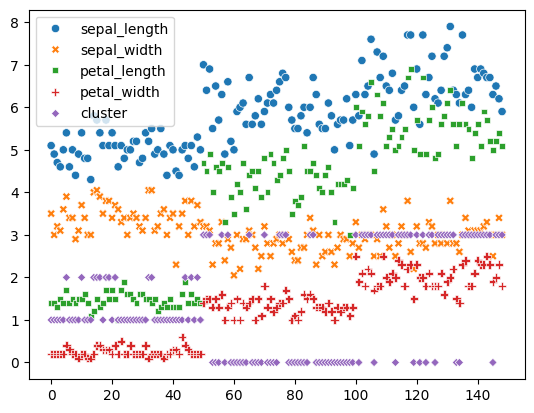

In [ ]:
sns.scatterplot(data = n_iris)

In [ ]:
# X = n_iris.drop('cluster', axis = 1)
# y = n_iris['cluster']

In [ ]:
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [ ]:
# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=3, random_state=42)

# kmeans.fit(X_scaled)

# y_pred = kmeans.predict(X_scaled)


In [ ]:
# from sklearn.metrics import silhouette_score

# score = silhouette_score(X_scaled, y_pred)

# print("Silhouette Score:", score)